In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parameter Estimation with $\chi^2$.

In this notebook we're going to do some simple explorations of parameter estimation using $\chi^2$.



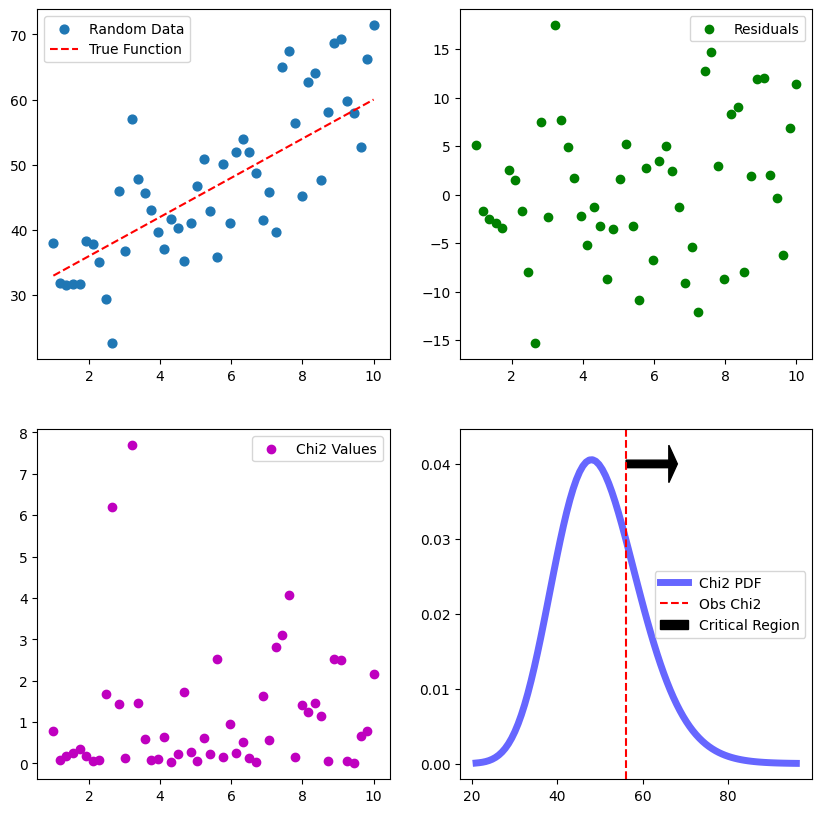


Observed Chi2:  56.12279361434375
Chi2 PDF Value:  0.029783613472554586
Chi2 CDF Value:  0.7437692774492559
Observed p-value:  0.2562307225507441


In [8]:
# Make some data!!
# Gonna be a set of noisy data drawn from a linear function
N = 50 # number of points per class
xmin = 1 
xmax = 10
slope = 3
offset = 30
noiseScaleFactor = 1
inject = False

X = np.zeros(N)
y = np.zeros(N)

xline = [xmin,xmax]
yline = [offset+xmin*slope,offset+slope*xmax]

X = np.linspace(xmin,xmax,N)
y_true = slope*X + offset



y = slope*X + offset

# We will explore the role that the size of the noise plays
# Why did I choose this value to begin with?
for i in range(0,N):
    y[i] += np.random.randn()*np.sqrt(X[i]*slope+offset)

#should we add outliers?
if inject:
    y[int(N/2)] *= 2
    y[int(N/2)+1] *= 2

# Calculate data!
deltaYvals = y - y_true  # Residuals
chi2vals = deltaYvals*deltaYvals/y_true # (d-y)^2/y

# Calculate statistics
obsChi2 = np.sum(chi2vals) # sum over array
pdfValue = stats.chi2.pdf(obsChi2,N) # What's the value of the Chi2 PDF at this observed chi2
cdfValue = stats.chi2.cdf(obsChi2,N) # Cumulative distribution function for Chi2 PDF, calculated over [-inf,Chi2]
pValue = 1-cdfValue #complement to the cdf, giving the upper tail p-value

fig, axs = plt.subplots(nrows=2,ncols=2,figsize=(10,10))

axs[0,0].scatter(X, y, s=40, label = "Random Data")
axs[0,0].plot(xline,yline,linestyle="--",color="r", label="True Function")
axs[0,0].legend()

axs[0,1].scatter(X,deltaYvals,label = "Residuals",c='g')
#axs[0,1].axhline(y=noise,color='r',linestyle="--",label = "+/- 1 std. dev.")
#axs[0,1].axhline(y=-1*noise,color='r',linestyle="--")
axs[0,1].legend()

axs[1,0].scatter(X,chi2vals,label = "Chi2 Values",color='m')
axs[1,0].legend()

chi2x = np.linspace(stats.chi2.ppf(0.0001, N), stats.chi2.ppf(0.9999, N), 100)
axs[1,1].plot(chi2x, stats.chi2.pdf(chi2x, N),
       'b-', lw=5, alpha=0.6, label='Chi2 PDF')
axs[1,1].axvline(x=obsChi2,c='r',linestyle="--",label = "Obs Chi2")
axs[1,1].arrow(obsChi2, 0.04, 10, 0, head_width=0.005, head_length=2, fc='k', ec='k',label="Critical Region")
axs[1,1].legend()
plt.show()

print("\nObserved Chi2: ",obsChi2)
print("Chi2 PDF Value: ",pdfValue)
print("Chi2 CDF Value: ",cdfValue)
print("Observed p-value: ",pValue)

Slope analysis: Chi2 =  53.980417270035844 , Min =  3.2460000000000004
Offset analysis: Chi2 =  55.23816774945942 , Min =  30.888


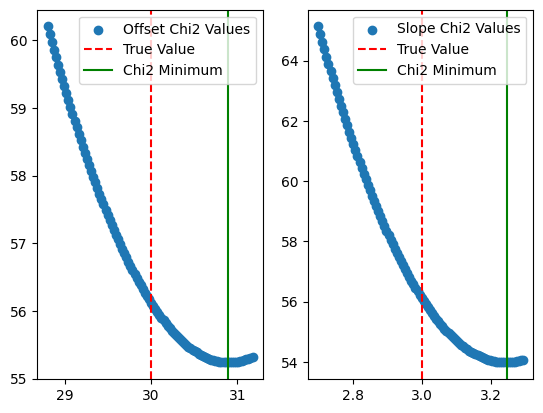

In [9]:
offsetSF = 25
slopeSF = 25

offsetChi2 = []
offsetPval = []
offsetVals = []
minOffset = 1E7
minChi2O = 1E7
for i in range(0,100):
    b = offset-offset/offsetSF + 2*offset/offsetSF/100*i
    offsetVals.append(b)
    y_alt = slope*X + b + 1e-6
    deltaYvals = y - y_alt
    chi2val = np.sum(deltaYvals*deltaYvals/y_alt)
    if chi2val < minChi2O:
        minOffset = b
        minChi2O = chi2val
    offsetChi2.append(chi2val)
    offsetPval.append(1-stats.chi2.cdf(chi2val,N))

offsetSF = 10
slopeSF = 10
slopeChi2 = []
slopePval = []
slopeVals = []
minSlope = 1E7
minChi2S = 1E7
for i in range(0,100):
    s = slope-slope/slopeSF + 2*slope/slopeSF/100*i
    slopeVals.append(s)
    y_alt = s*X + offset + 1e-6
    deltaYvals = y - y_alt
    chi2val = np.sum(deltaYvals*deltaYvals/y_alt)
    if chi2val < minChi2S:
        minSlope = s
        minChi2S = chi2val
    slopeChi2.append(chi2val)
    slopePval.append(1-stats.chi2.cdf(chi2val,N))

print("Slope analysis: Chi2 = ", minChi2S,", Min = ", minSlope)
print("Offset analysis: Chi2 = ", minChi2O,", Min = ", minOffset)

fig, axs2 = plt.subplots(nrows=1,ncols=2)

axs2[0].scatter(offsetVals,offsetChi2,label = "Offset Chi2 Values")
axs2[0].axvline(x=offset,c='r',linestyle="--",label = "True Value")
axs2[0].axvline(x=minOffset,c='g',linestyle="-",label = "Chi2 Minimum")
axs2[0].legend()
axs2[1].scatter(slopeVals,slopeChi2,label = "Slope Chi2 Values")
axs2[1].axvline(x=slope,c='r',linestyle="--",label = "True Value")
axs2[1].axvline(x=minSlope,c='g',linestyle="-",label = "Chi2 Minimum")
axs2[1].legend()

In [10]:
def findMinima1D(XX,yy):
    offsetSF = 5
    slopeSF = 5
    mOffset = 1E7
    minY = 1E7
    for i in range(0,100):
        b = offset-offset/offsetSF + 2*offset/offsetSF/100*i
        y_alt = slope*XX + b 
        deltaYvals = yy - y_alt
        chi2val = np.sum(deltaYvals*deltaYvals/y_alt)
        if chi2val < minY:
            mOffset = b
            minY = chi2val

    mSlope = 1E7
    minY = 1E7
    for i in range(0,100):
        s = slope-slope/slopeSF + 2*slope/slopeSF/100*i
        y_alt = s*XX + offset 
        deltaYvals = yy - y_alt
        chi2val = np.sum(deltaYvals*deltaYvals/y_alt)
        if chi2val < minY:
            mSlope = s
            minY = chi2val

    return mSlope, mOffset

nTrial = 5000
slopeFit = np.zeros(nTrial)
offsetFit = np.zeros(nTrial)

for i in range(0,nTrial):
    yy = slope*X + offset
    for j in range(0,N):
        yy[j] += np.random.randn()*np.sqrt(X[j]*slope+offset)
    ms,mo = findMinima1D(X,yy)
    slopeFit[i] = ms
    offsetFit[i] = mo

slopeFit = np.sort(slopeFit)
offsetFit = np.sort(offsetFit)

slopeStd1 = slopeFit[int(nTrial*0.15865)]
slopeStd2 = slopeFit[int(nTrial*(1-0.15865))]
offsetStd1 = offsetFit[int(nTrial*0.15865)]
offsetStd2 = offsetFit[int(nTrial*(1-0.15865))]

print("\nSlope Std Dev: ", slopeStd1, "-", slopeStd2, ", avg: ",(slopeStd2-slopeStd1)/2)
print("Offset Std Dev: ", offsetStd1, "-", offsetStd2, ", avg: ",(offsetStd2-offsetStd1)/2)

offsetChi2p1 = 0
offsetChi2p2 = 0
foundFirst1 = False
foundFirst2 = False
for i in range(0,len(offsetChi2)):
    if (offsetChi2[i]< (minChi2O+1)) and (foundFirst1 == False):
        offsetChi2p1 = offsetVals[i]
        foundFirst1 = True

    if (offsetChi2[i]> (minChi2O+1)) and (foundFirst1 == True) and (foundFirst2==False):
        offsetChi2p2 = offsetVals[i]
        foundFirst2 = True


slopeChi2p1 = 0
slopeChi2p2 = 0
foundFirst1 = False
foundFirst2 = False
for i in range(0,len(slopeChi2)):
    if (slopeChi2[i]< (minChi2S+1)) and (foundFirst1 == False):
        slopeChi2p1 = slopeVals[i]
        foundFirst1 = True

    if (slopeChi2[i]> (minChi2O+1)) and (foundFirst1 == True) and (foundFirst2==False):
        slopeChi2p2 = slopeVals[i]
        foundFirst2 = True

print("\nSlope range from Chi2: ",slopeChi2p1, "-", slopeChi2p2, ", avg: ",(slopeChi2p2 - slopeChi2p1)/2) 
print("Offset range from Chi2: ",offsetChi2p1, "-", offsetChi2p2, ", avg: ",(offsetChi2p2 - offsetChi2p1)/2)



Slope Std Dev:  2.916 - 3.2399999999999998 , avg:  0.16199999999999992
Offset Std Dev:  29.52 - 31.439999999999998 , avg:  0.9599999999999991

Slope range from Chi2:  3.0780000000000003 - 0 , avg:  -1.5390000000000001
Offset range from Chi2:  29.952 - 0 , avg:  -14.976


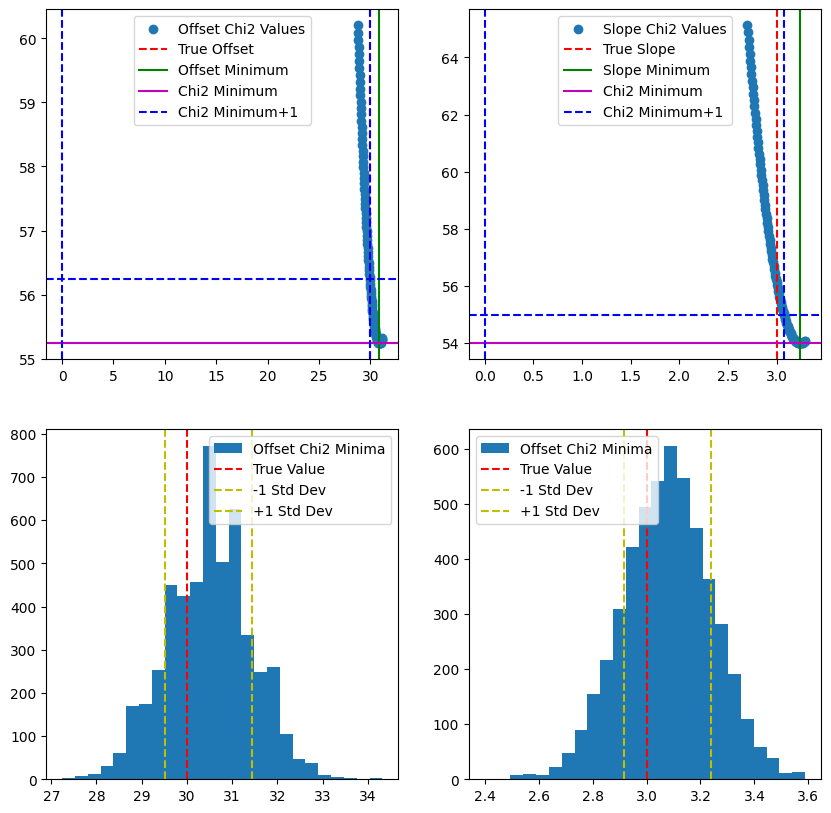


From MC trials analysis: 
Slope Std Dev:  2.916  -  3.2399999999999998 , avg:  0.16199999999999992
Offset Std Dev:  29.52  -  31.439999999999998 , avg:  0.9599999999999991

From Chi2 analysis: 
Slope Std Dev:  3.0780000000000003 - 0 , avg:  -1.5390000000000001
Offset Std Dev:  29.952 - 0 , avg:  -14.976


In [11]:
fig, axs3 = plt.subplots(nrows=2,ncols=2,figsize=(10,10))

axs3[0,0].scatter(offsetVals,offsetChi2,label = "Offset Chi2 Values")
axs3[0,0].axvline(x=offset,c='r',linestyle="--",label = "True Offset")
axs3[0,0].axvline(x=minOffset,c='g',linestyle="-",label = "Offset Minimum")
axs3[0,0].axhline(y=minChi2O,c='m',linestyle="-",label = "Chi2 Minimum")
axs3[0,0].axhline(y=minChi2O+1,c='b',linestyle="--",label = "Chi2 Minimum+1")
axs3[0,0].axvline(x=offsetChi2p1,c='b',linestyle="--")
axs3[0,0].axvline(x=offsetChi2p2,c='b',linestyle="--")
axs3[0,0].legend()
axs3[0,1].scatter(slopeVals,slopeChi2,label = "Slope Chi2 Values")
axs3[0,1].axvline(x=slope,c='r',linestyle="--",label = "True Slope")
axs3[0,1].axvline(x=minSlope,c='g',linestyle="-",label = "Slope Minimum")
axs3[0,1].axhline(y=minChi2S,c='m',linestyle="-",label = "Chi2 Minimum")
axs3[0,1].axhline(y=minChi2S+1,c='b',linestyle="--",label = "Chi2 Minimum+1")
axs3[0,1].axvline(x=slopeChi2p1,c='b',linestyle="--")
axs3[0,1].axvline(x=slopeChi2p2,c='b',linestyle="--")
axs3[0,1].legend()

axs3[1,0].hist(offsetFit,25,label = "Offset Chi2 Minima")
axs3[1,0].axvline(x=offset,c='r',linestyle="--",label = "True Value")
axs3[1,0].axvline(x=offsetStd1,c='y',linestyle="--",label = "-1 Std Dev")
axs3[1,0].axvline(x=offsetStd2,c='y',linestyle="--",label = "+1 Std Dev")

axs3[1,0].legend()
axs3[1,1].hist(slopeFit,25,label = "Offset Chi2 Minima")
axs3[1,1].axvline(x=slope,c='r',linestyle="--",label = "True Value")
axs3[1,1].axvline(x=slopeStd1,c='y',linestyle="--",label = "-1 Std Dev")
axs3[1,1].axvline(x=slopeStd2,c='y',linestyle="--",label = "+1 Std Dev")
axs3[1,1].legend()
plt.show()

print("\nFrom MC trials analysis: ")
print("Slope Std Dev: ", slopeStd1, " - ", slopeStd2, ", avg: ",(slopeStd2-slopeStd1)/2)
print("Offset Std Dev: ", offsetStd1, " - ", offsetStd2, ", avg: ",(offsetStd2-offsetStd1)/2)

print("\nFrom Chi2 analysis: ")
print("Slope Std Dev: ",slopeChi2p1, "-", slopeChi2p2, ", avg: ",(slopeChi2p2 - slopeChi2p1)/2) 
print("Offset Std Dev: ",offsetChi2p1, "-", offsetChi2p2, ", avg: ",(offsetChi2p2 - offsetChi2p1)/2)

Minima:
 Chi2 53.39085780276913 
 Slope:  3.4848 
 Offset:  28.44


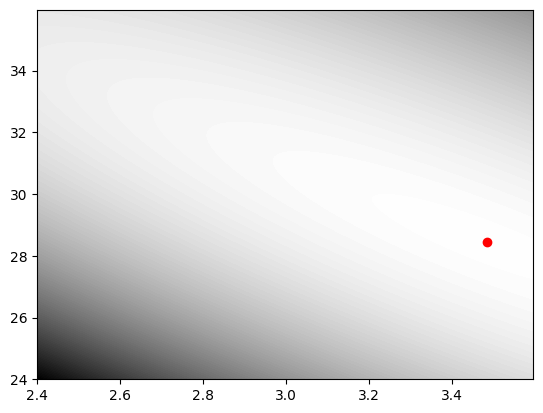

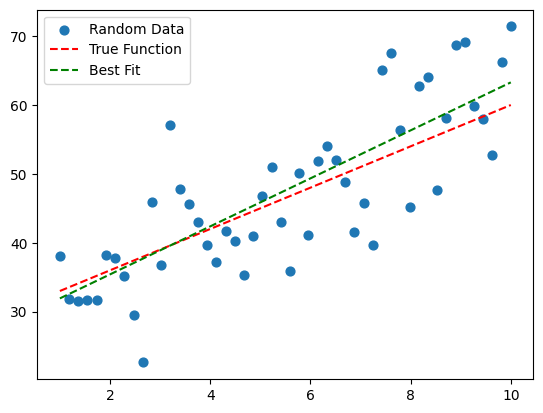

In [12]:
offsetSF = 5
slopeSF = 5
steps = 500
twodChi2 = np.zeros(shape=(steps,steps))
twodSlopeVals = np.zeros(steps)
twodOffsetVals = np.zeros(steps)
minOffset2 = 1E7
minSlope2 = 1E7
minY = 1E7
for i in range(0,steps):
    b = offset-offset/offsetSF + 2*offset/offsetSF/steps*i
    twodOffsetVals[i] = b

    for j in range(0,steps):
        s = slope-slope/slopeSF + 2*slope/slopeSF/steps*j
        if i == 0:
            twodSlopeVals[j] = s

        y_alt = s*X + b
        deltaYvals = y - y_alt
        chi2val = np.sum(deltaYvals*deltaYvals/y_alt)
        twodChi2[i,j] = chi2val
        if chi2val < minY:
            minSlope2 = s
            minOffset2 = b
            minY = chi2val

print("Minima:\n Chi2", minY, "\n Slope: ", minSlope2, "\n Offset: ", minOffset2)
plt.contourf(twodSlopeVals,twodOffsetVals,twodChi2,levels = 100,cmap="binary")
plt.plot(minSlope2,minOffset2,'ro')
plt.show()

ybest = [minOffset2+xmin*minSlope2,minOffset2+xmax*minSlope2]
plt.scatter(X, y, s=40, label = "Random Data")
plt.plot(xline,yline,linestyle="--",color="r", label="True Function")
plt.plot(xline,ybest,linestyle="--",color="g", label="Best Fit")
plt.legend()
plt.show()